In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import json

model = tf.keras.models.load_model('app/best_model.keras')

with open('app/class_names.json', 'r') as f:
    class_names = json.load(f)

print("Model loaded. Total layers:", len(model.layers))

Model loaded. Total layers: 158


In [2]:
for layer in model.layers:
    if 'conv' in layer.name.lower() and len(layer.output.shape) == 4:
        last_conv_layer_name = layer.name

print("Last convolutional layer found:", last_conv_layer_name)

Last convolutional layer found: Conv_1_bn


In [9]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs, 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [10]:
import os

test_class = class_names['5']
test_folder = os.path.join('data/New Plant Diseases Dataset(Augmented)/new-plant-diseases-dataset-augmented/valid', test_class)
test_image_name = os.listdir(test_folder)[0]
test_image_path = os.path.join(test_folder, test_image_name)

img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

plt.matshow(heatmap)
plt.title("Raw Grad-CAM Heatmap")
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/New Plant Diseases Dataset(Augmented)/new-plant-diseases-dataset-augmented/valid\\Cherry_(including_sour)___Powdery_mildew'

In [8]:
import os

valid_dir_found = None
for root, dirs, files in os.walk('data'):
    if os.path.basename(root).lower() == 'valid':
        valid_dir_found = root
        break

print("Valid folder path:", valid_dir_found)

Valid folder path: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid


In [11]:
test_class = class_names['5']
print("Looking for class:", repr(test_class))

available_folders = os.listdir(valid_dir_found)
print("\nDoes it exist exactly as-is?", test_class in available_folders)

similar = [f for f in available_folders if 'Cherry' in f]
print("\nSimilar folder names found:", similar)

Looking for class: 'Cherry_(including_sour)___Powdery_mildew'

Does it exist exactly as-is? True

Similar folder names found: ['Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew']


Test image path: data\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid\Cherry_(including_sour)___Powdery_mildew\00e0a4ab-ecbd-4560-a71c-b19d86bb087c___FREC_Pwd.M 4917.JPG


C:\Users\MANYA BHATT\anaconda3\envs\cropcare\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


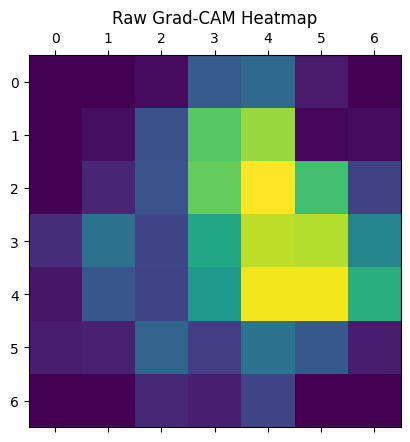

In [12]:
test_folder = os.path.join(valid_dir_found, test_class)
test_image_name = os.listdir(test_folder)[0]
test_image_path = os.path.join(test_folder, test_image_name)

print("Test image path:", test_image_path)

img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

plt.matshow(heatmap)
plt.title("Raw Grad-CAM Heatmap")
plt.show()

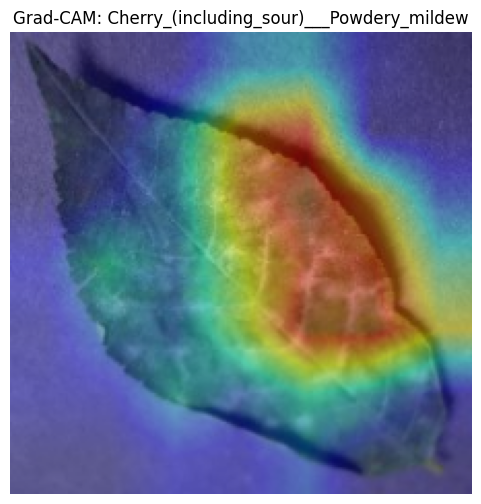

In [13]:
import cv2

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    return superimposed

result = overlay_gradcam(test_image_path, heatmap)

plt.figure(figsize=(6, 6))
plt.imshow(result)
plt.title(f"Grad-CAM: {test_class}")
plt.axis('off')
plt.show()

In [15]:
import cv2
import numpy as np

def estimate_severity(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    healthy_mask = cv2.inRange(hsv, lower_green, upper_green)

    total_leaf_pixels = np.count_nonzero(hsv[:, :, 1] > 20)
    healthy_pixels = np.count_nonzero(healthy_mask)

    if total_leaf_pixels == 0:
        return 0.0

    diseased_pixels = total_leaf_pixels - healthy_pixels
    severity_pct = (diseased_pixels / total_leaf_pixels) * 100
    severity_pct = max(0, min(100, severity_pct))

    return round(severity_pct, 1)

In [16]:
severity = estimate_severity(test_image_path)
print(f"Estimated severity: {severity}%")
print(f"Disease: {test_class}")

Estimated severity: 35.6%
Disease: Cherry_(including_sour)___Powdery_mildew


In [17]:
healthy_class = [c for c in class_names.values() if 'healthy' in c.lower()][0]
healthy_folder = os.path.join(valid_dir_found, healthy_class)
healthy_image_path = os.path.join(healthy_folder, os.listdir(healthy_folder)[0])

healthy_severity = estimate_severity(healthy_image_path)
print(f"Estimated severity on a HEALTHY leaf: {healthy_severity}%")

Estimated severity on a HEALTHY leaf: 74.3%


In [18]:
visualize_severity_mask(healthy_image_path)

NameError: name 'visualize_severity_mask' is not defined

In [19]:
import matplotlib.pyplot as plt

def visualize_severity_mask(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    healthy_mask = cv2.inRange(hsv, lower_green, upper_green)
    diseased_mask = cv2.bitwise_not(healthy_mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[1].imshow(healthy_mask, cmap='Greens')
    axes[1].set_title("Healthy Tissue (detected)")
    axes[2].imshow(diseased_mask, cmap='Reds')
    axes[2].set_title("Diseased/Discolored (detected)")
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

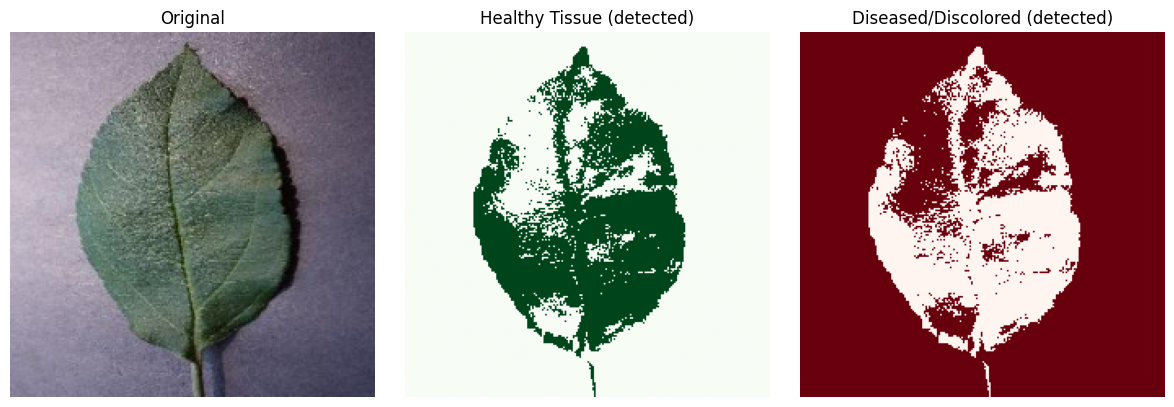

In [20]:
visualize_severity_mask(healthy_image_path)

In [21]:
img = cv2.imread(healthy_image_path)
img = cv2.resize(img, (224, 224))
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

center_region = hsv[80:144, 80:144]
h_vals = center_region[:, :, 0].flatten()
s_vals = center_region[:, :, 1].flatten()
v_vals = center_region[:, :, 2].flatten()

print("Hue range (center of leaf):", h_vals.min(), "-", h_vals.max(), "| median:", int(np.median(h_vals)))
print("Saturation range:", s_vals.min(), "-", s_vals.max(), "| median:", int(np.median(s_vals)))
print("Value range:", v_vals.min(), "-", v_vals.max(), "| median:", int(np.median(v_vals)))

Hue range (center of leaf): 38 - 79 | median: 63
Saturation range: 12 - 255 | median: 45
Value range: 31 - 191 | median: 109


In [22]:
lower_green = np.array([25, 15, 20])
upper_green = np.array([90, 255, 255])

hsv = cv2.cvtColor(cv2.resize(cv2.imread(healthy_image_path), (224, 224)), cv2.COLOR_BGR2HSV)
healthy_mask = cv2.inRange(hsv, lower_green, upper_green)

total_leaf_pixels = np.count_nonzero(hsv[:, :, 1] > 10)
healthy_pixels = np.count_nonzero(healthy_mask)
severity_pct = round(max(0, min(100, ((total_leaf_pixels - healthy_pixels) / total_leaf_pixels) * 100)), 1)

print("New severity estimate on healthy leaf:", severity_pct, "%")

New severity estimate on healthy leaf: 65.4 %


In [23]:
def estimate_severity(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    a_channel = lab[:, :, 1]

    _, diseased_mask = cv2.threshold(a_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    total_pixels = a_channel.size
    diseased_pixels = np.count_nonzero(diseased_mask)
    severity_pct = (diseased_pixels / total_pixels) * 100

    return round(severity_pct, 1)

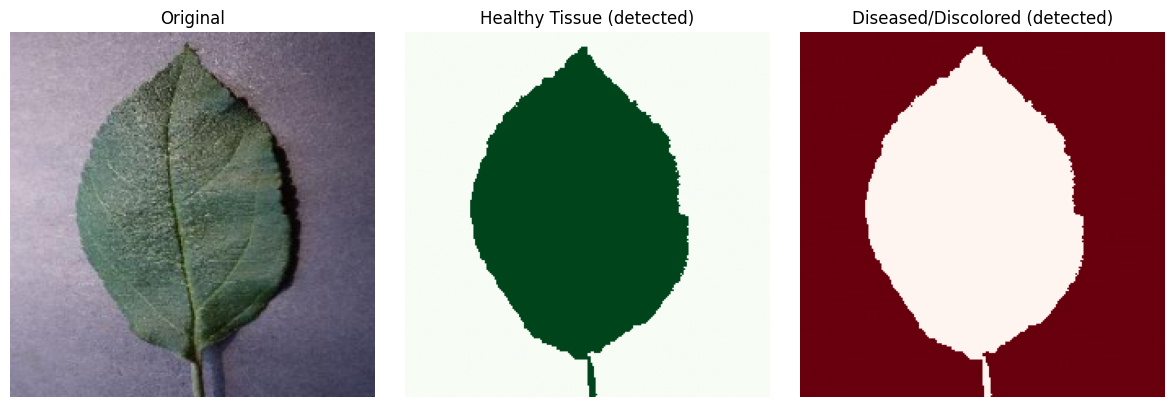

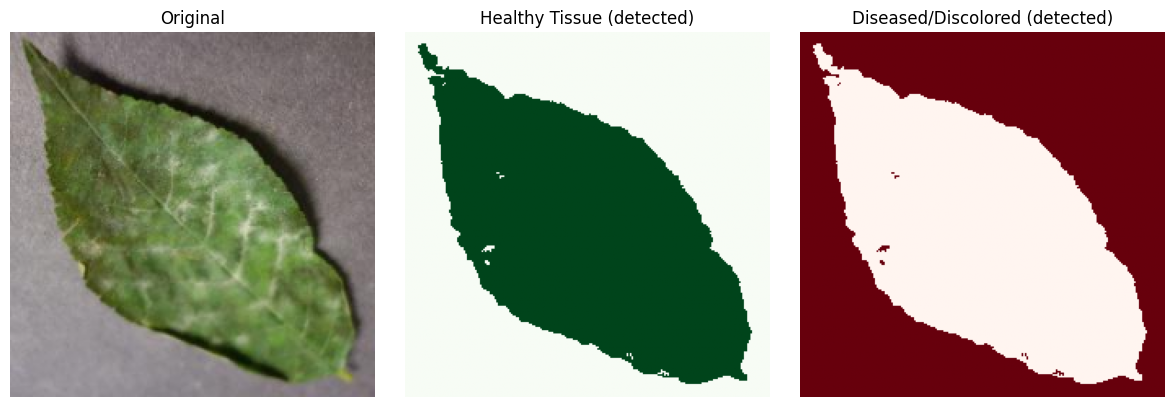

In [24]:
def visualize_severity_mask(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    a_channel = lab[:, :, 1]

    _, diseased_mask = cv2.threshold(a_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    healthy_mask = cv2.bitwise_not(diseased_mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[1].imshow(healthy_mask, cmap='Greens')
    axes[1].set_title("Healthy Tissue (detected)")
    axes[2].imshow(diseased_mask, cmap='Reds')
    axes[2].set_title("Diseased/Discolored (detected)")
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_severity_mask(healthy_image_path)
visualize_severity_mask(test_image_path)

In [25]:
print("Healthy leaf severity:", estimate_severity(healthy_image_path), "%")
print("Diseased leaf severity:", estimate_severity(test_image_path), "%")

Healthy leaf severity: 65.0 %
Diseased leaf severity: 54.2 %


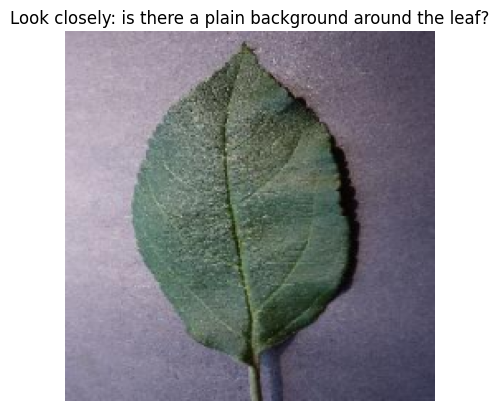

In [26]:
img = cv2.imread(healthy_image_path)
img = cv2.resize(img, (224, 224))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Look closely: is there a plain background around the leaf?")
plt.axis('off')
plt.show()

In [27]:
def estimate_severity(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]
    _, leaf_mask = cv2.threshold(saturation, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    a_channel = lab[:, :, 1]

    leaf_pixel_values = a_channel[leaf_mask > 0]

    if len(leaf_pixel_values) == 0:
        return 0.0

    otsu_thresh, _ = cv2.threshold(leaf_pixel_values, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    diseased_within_leaf = np.count_nonzero((a_channel > otsu_thresh) & (leaf_mask > 0))
    total_leaf_pixels = np.count_nonzero(leaf_mask > 0)

    severity_pct = (diseased_within_leaf / total_leaf_pixels) * 100
    return round(severity_pct, 1)

In [28]:
print("Healthy leaf severity:", estimate_severity(healthy_image_path), "%")
print("Diseased leaf severity:", estimate_severity(test_image_path), "%")

Healthy leaf severity: 54.5 %
Diseased leaf severity: 34.9 %


In [29]:
def estimate_severity_from_heatmap(heatmap, threshold=0.5):
    binary_map = heatmap > threshold
    severity_pct = (np.count_nonzero(binary_map) / binary_map.size) * 100
    return round(severity_pct, 1)

In [30]:
diseased_heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
diseased_severity = estimate_severity_from_heatmap(diseased_heatmap)
print("Diseased leaf severity (from heatmap):", diseased_severity, "%")

Diseased leaf severity (from heatmap): 24.5 %


In [31]:
healthy_img = image.load_img(healthy_image_path, target_size=(224, 224))
healthy_array = image.img_to_array(healthy_img)
healthy_array = np.expand_dims(healthy_array, axis=0) / 255.0

healthy_heatmap = make_gradcam_heatmap(healthy_array, model, last_conv_layer_name)
healthy_severity = estimate_severity_from_heatmap(healthy_heatmap)
print("Healthy leaf severity (from heatmap):", healthy_severity, "%")

Healthy leaf severity (from heatmap): 16.3 %


In [32]:
sample_classes = random.sample(list(class_names.values()), 8)
for cls in sample_classes:
    folder = os.path.join(valid_dir_found, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    
    img_loaded = image.load_img(img_path, target_size=(224, 224))
    arr = np.expand_dims(image.img_to_array(img_loaded), axis=0) / 255.0
    hm = make_gradcam_heatmap(arr, model, last_conv_layer_name)
    sev = estimate_severity_from_heatmap(hm)
    
    label = "HEALTHY" if "healthy" in cls.lower() else "DISEASED"
    print(f"[{label}] {cls}: {sev}%")

NameError: name 'random' is not defined

In [33]:
import random

In [34]:
sample_classes = random.sample(list(class_names.values()), 8)
for cls in sample_classes:
    folder = os.path.join(valid_dir_found, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    
    img_loaded = image.load_img(img_path, target_size=(224, 224))
    arr = np.expand_dims(image.img_to_array(img_loaded), axis=0) / 255.0
    hm = make_gradcam_heatmap(arr, model, last_conv_layer_name)
    sev = estimate_severity_from_heatmap(hm)
    
    label = "HEALTHY" if "healthy" in cls.lower() else "DISEASED"
    print(f"[{label}] {cls}: {sev}%")

[HEALTHY] Corn_(maize)___healthy: 18.4%
[DISEASED] Pepper,_bell___Bacterial_spot: 16.3%
[DISEASED] Corn_(maize)___Northern_Leaf_Blight: 12.2%
[DISEASED] Tomato___Spider_mites Two-spotted_spider_mite: 16.3%
[DISEASED] Grape___Esca_(Black_Measles): 30.6%
[HEALTHY] Raspberry___healthy: 16.3%
[DISEASED] Peach___Bacterial_spot: 4.1%
[DISEASED] Corn_(maize)___Common_rust_: 26.5%
